## MLS WS 2025/26 Exercise 3b: Network Intrusion Detection (37P)
*Adapted from an exercise created by Dennis Eisermann*

In this exercise, you classify the [CIC-IDS-2017](https://www.unb.ca/cic/datasets/ids-2017.html) cybersecurity dataset. This dataset contains network traffic data to train and evaluate [network intrusion detection systems](https://en.wikipedia.org/wiki/Intrusion_detection_system). The dataset consists of modern network traffic and contains more than 2.8 million network packets recorded over a seven-day period in a real network environment. The dataset covers both regular traffic and multiple attack scenarios like [Brute Force](https://en.wikipedia.org/wiki/Brute-force_search), [DoS](https://en.wikipedia.org/wiki/Denial-of-service_attack), and [Web Attacks](https://owasp.org/www-project-top-ten/). The data will be used for a multiclass classification task based on the feature "Attack Type". [Deep Neural Network (DNN)](https://en.wikipedia.org/wiki/Deep_learning) architectures are used to divide network flow samples into benign and different attack types.

### Setup

In [1]:
%pip install numpy pandas scikit-learn imbalanced-learn
%pip install torch --index-url https://download.pytorch.org/whl/cu126
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu126
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Download [MachineLearningCSV.zip](http://cicresearch.ca/CICDataset/CIC-IDS-2017/Dataset/CIC-IDS-2017/CSVs/MachineLearningCSV.zip) version from the CIC-IDS-2017 dataset.

### Task 1 – Exploration of the Dataset (14 Points)

Create an understanding of the dataset. Additionally, we want a more in-depth understanding of the attack classes and their features to get an idea of how a classifier could work.

1. Unzip MachineLearningCSV.zip and load all contained CSV files and concatenate them into one dataframe. Show the top 5 rows for a first impression of the dataset. (1 Point)

In [12]:
import zipfile
import pandas as pd
import os

# Path to your ZIP file
zip_file = 'MachineLearningCSV.zip'

# Directory to extract files
extract_dir = 'unzipped_files'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Collect all CSV files (including nested folders)
csv_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

# Check if we found any CSV files
if not csv_files:
    raise ValueError("No CSV files found in the ZIP archive.")

# Read and concatenate all CSV files
dfs = [pd.read_csv(file) for file in csv_files]
df = pd.concat(dfs, ignore_index=True)

# Show top 5 rows
print("Top 5 rows of the combined dataset:")
print(combined_df.head())


Top 5 rows of the combined dataset:
    Destination Port   Flow Duration   Total Fwd Packets  \
0                 88             640                   7   
1                 88             900                   9   
2                 88            1205                   7   
3                 88             511                   7   
4                 88             773                   9   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        4                          440   
1                        4                          600   
2                        4                         2776   
3                        4                          452   
4                        4                          612   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                           358                     220   
1                          2944                     300   
2                          2830                    1388   
3           

2. Print the column statistics and data types. (1 Point)

In [13]:
# print column statistics and data types
# Alle Spalten anzeigen
pd.set_option('display.max_columns', None)

# Optional: alle Zeilen anzeigen
pd.set_option('display.max_rows', None)

# Optional: max Spaltenbreite
pd.set_option('display.max_colwidth', None)

# Dann describe() ausgeben
df.describe(include='all').transpose()


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,NaN,NaN,NaN,8071.482501,18283.632173,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,NaN,NaN,NaN,14785663.929522,33653744.085842,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,NaN,NaN,NaN,9.36116,749.672793,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,NaN,NaN,NaN,10.39377,997.388269,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,NaN,NaN,NaN,549.302415,9993.589229,0.0,12.0,62.0,187.0,12900000.0
Total Length of Bwd Packets,2830743.0,NaN,NaN,NaN,16162.642546,2263088.051709,0.0,0.0,123.0,482.0,655453030.0
Fwd Packet Length Max,2830743.0,NaN,NaN,NaN,207.599941,717.184842,0.0,6.0,37.0,81.0,24820.0
Fwd Packet Length Min,2830743.0,NaN,NaN,NaN,18.713656,60.339345,0.0,0.0,2.0,36.0,2325.0
Fwd Packet Length Mean,2830743.0,NaN,NaN,NaN,58.201939,186.091157,0.0,6.0,34.0,50.0,5940.857143
Fwd Packet Length Std,2830743.0,NaN,NaN,NaN,68.910134,281.187092,0.0,0.0,0.0,26.162951,7125.596846


In [14]:
print(df.dtypes)

 Destination Port                 int64
 Flow Duration                    int64
 Total Fwd Packets                int64
 Total Backward Packets           int64
Total Length of Fwd Packets       int64
 Total Length of Bwd Packets      int64
 Fwd Packet Length Max            int64
 Fwd Packet Length Min            int64
 Fwd Packet Length Mean         float64
 Fwd Packet Length Std          float64
Bwd Packet Length Max             int64
 Bwd Packet Length Min            int64
 Bwd Packet Length Mean         float64
 Bwd Packet Length Std          float64
Flow Bytes/s                    float64
 Flow Packets/s                 float64
 Flow IAT Mean                  float64
 Flow IAT Std                   float64
 Flow IAT Max                     int64
 Flow IAT Min                     int64
Fwd IAT Total                     int64
 Fwd IAT Mean                   float64
 Fwd IAT Std                    float64
 Fwd IAT Max                      int64
 Fwd IAT Min                      int64


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

3. Do you notice something odd in the statistics for some columns? Print all column names that have overall values that might be a problem for training a classifier. (3 Points)
   *Note: There are three different types of "oddities" you show be able to find in the statistics.*

In [16]:
# Columns with negative values
for column in df.select_dtypes(include=['number']).columns:
    if (df[column] < 0).any():
        print(f"Column '{column}' contains negative values.")



Column ' Flow Duration' contains negative values.
Column 'Flow Bytes/s' contains negative values.
Column ' Flow Packets/s' contains negative values.
Column ' Flow IAT Mean' contains negative values.
Column ' Flow IAT Max' contains negative values.
Column ' Flow IAT Min' contains negative values.
Column ' Fwd IAT Min' contains negative values.
Column ' Fwd Header Length' contains negative values.
Column ' Bwd Header Length' contains negative values.
Column ' Fwd Header Length.1' contains negative values.
Column 'Init_Win_bytes_forward' contains negative values.
Column ' Init_Win_bytes_backward' contains negative values.
Column ' min_seg_size_forward' contains negative values.


In [17]:
const_features = df.columns[df.nunique() == 1]

print("Columns with constant values:")
for col in const_features:
    print("-", col)



Columns with constant values:
-  Bwd PSH Flags
-  Bwd URG Flags
- Fwd Avg Bytes/Bulk
-  Fwd Avg Packets/Bulk
-  Fwd Avg Bulk Rate
-  Bwd Avg Bytes/Bulk
-  Bwd Avg Packets/Bulk
- Bwd Avg Bulk Rate


In [18]:
import numpy as np

# Numerische Spalten auswählen
num_cols = df.select_dtypes(include=[np.number]).columns

# Spalten mit Inf/-Inf
inf_cols = df[num_cols].columns.to_series()[np.isinf(df[num_cols]).any()]

# Ausgabe als saubere Liste
print("Spalten mit Inf-Werten:")
for col in inf_cols:
    print("-", col)



Spalten mit Inf-Werten:
- Flow Bytes/s
-  Flow Packets/s


4. Show how many different values each column contains. (1 Point)

In [19]:
# Count unique values per column
unique_counts = df.nunique()
print("Number of unique values per column:")
print(unique_counts)

Number of unique values per column:
 Destination Port                 53805
 Flow Duration                  1050899
 Total Fwd Packets                 1432
 Total Backward Packets            1747
Total Length of Fwd Packets       17928
 Total Length of Bwd Packets      64698
 Fwd Packet Length Max             5279
 Fwd Packet Length Min              384
 Fwd Packet Length Mean           99716
 Fwd Packet Length Std           253909
Bwd Packet Length Max              4838
 Bwd Packet Length Min              583
 Bwd Packet Length Mean          147614
 Bwd Packet Length Std           248869
Flow Bytes/s                    1593908
 Flow Packets/s                 1240164
 Flow IAT Mean                  1166311
 Flow IAT Std                   1056642
 Flow IAT Max                    580289
 Flow IAT Min                    136316
Fwd IAT Total                    493098
 Fwd IAT Mean                    737737
 Fwd IAT Std                     700313
 Fwd IAT Max                     437316
 Fwd

5. Count the duplicate rows in as total numbers and as percentage. (1 Points)

In [20]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

# Calculate percentage
duplicate_percentage = (duplicate_count / df.shape[0]) * 100

print(f"Total duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")

Total duplicate rows: 308381
Percentage of duplicate rows: 10.89%


6. Which column contains information about the kind of attack? Plot the number of rows for each attack. (1 Point)
   *Note: There are white spaces in some of the column names.*

Possible attack column(s): ['Label']


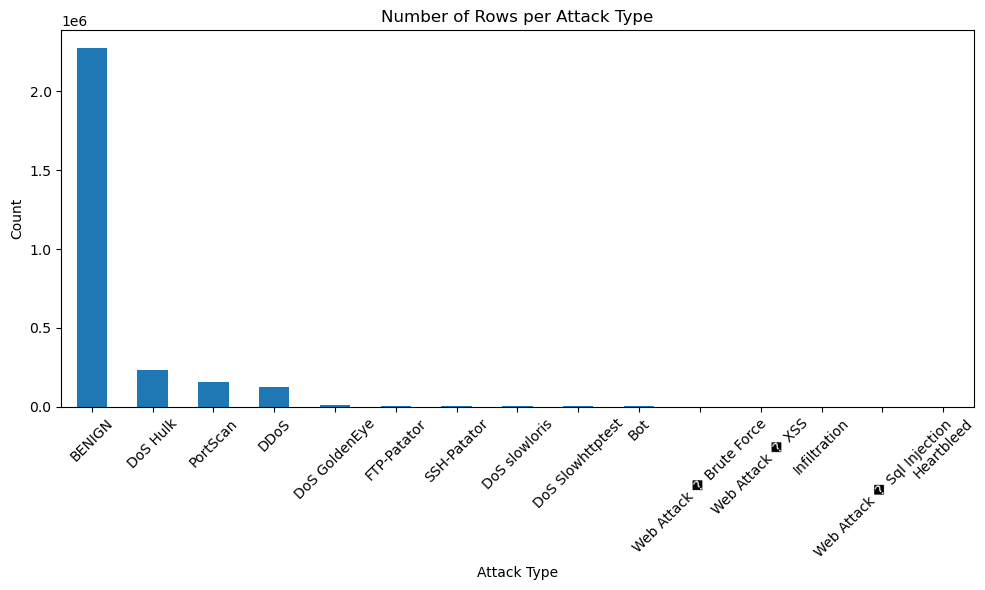

In [21]:
import matplotlib.pyplot as plt

# Strip whitespace from column names for easier handling
df.columns = df.columns.str.strip()

# Identify the column that contains attack information
# Usually it's something like 'attack' or 'Attack_Type'
attack_col = [col for col in df.columns if 'attack' in col.lower() or 'label' in col.lower()]
print(f"Possible attack column(s): {attack_col}")

# Assuming the first match is the attack column
attack_column = attack_col[0]

# Count occurrences of each attack type
attack_counts = df[attack_column].value_counts()

# Plot the attack distribution
plt.figure(figsize=(10, 6))
attack_counts.plot(kind='bar')
plt.title('Number of Rows per Attack Type')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

7. Show the distribution of attacks in a pie chart with the value labels in the plot formatted as percentage. Attacks less frequent than 4% of the data should be aggregated into a single bucket called "other". (2 Points)

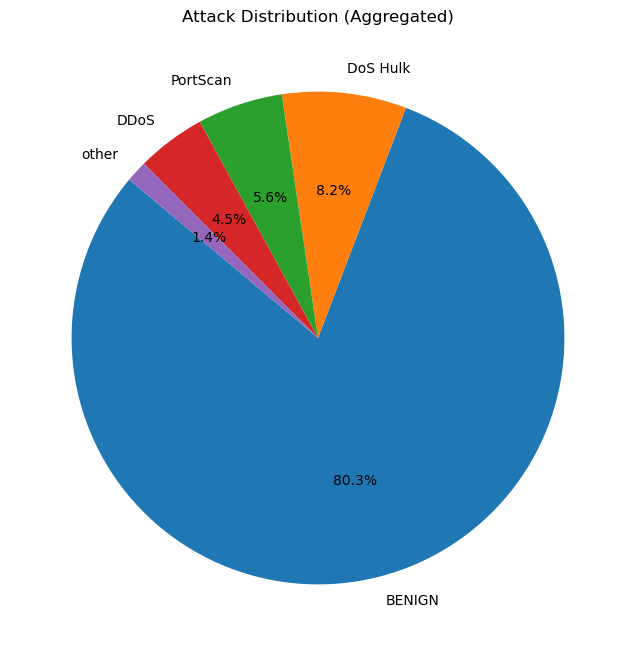

In [22]:
import matplotlib.pyplot as plt

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Identify attack column (assuming it's already found as attack_column)
attack_counts = df[attack_column].value_counts()

# Calculate percentages
attack_percent = (attack_counts / attack_counts.sum()) * 100

# Separate attacks less than 4% into "other"
major_attacks = attack_percent[attack_percent >= 4]
other_attacks = attack_percent[attack_percent < 4].sum()

# Combine into one series
final_attacks = major_attacks.copy()
final_attacks['other'] = other_attacks

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(final_attacks, labels=final_attacks.index, autopct='%1.1f%%', startangle=140)
plt.title('Attack Distribution (Aggregated)')
plt.show()

8. Visualize the correlations between numeric features. (1 Point)

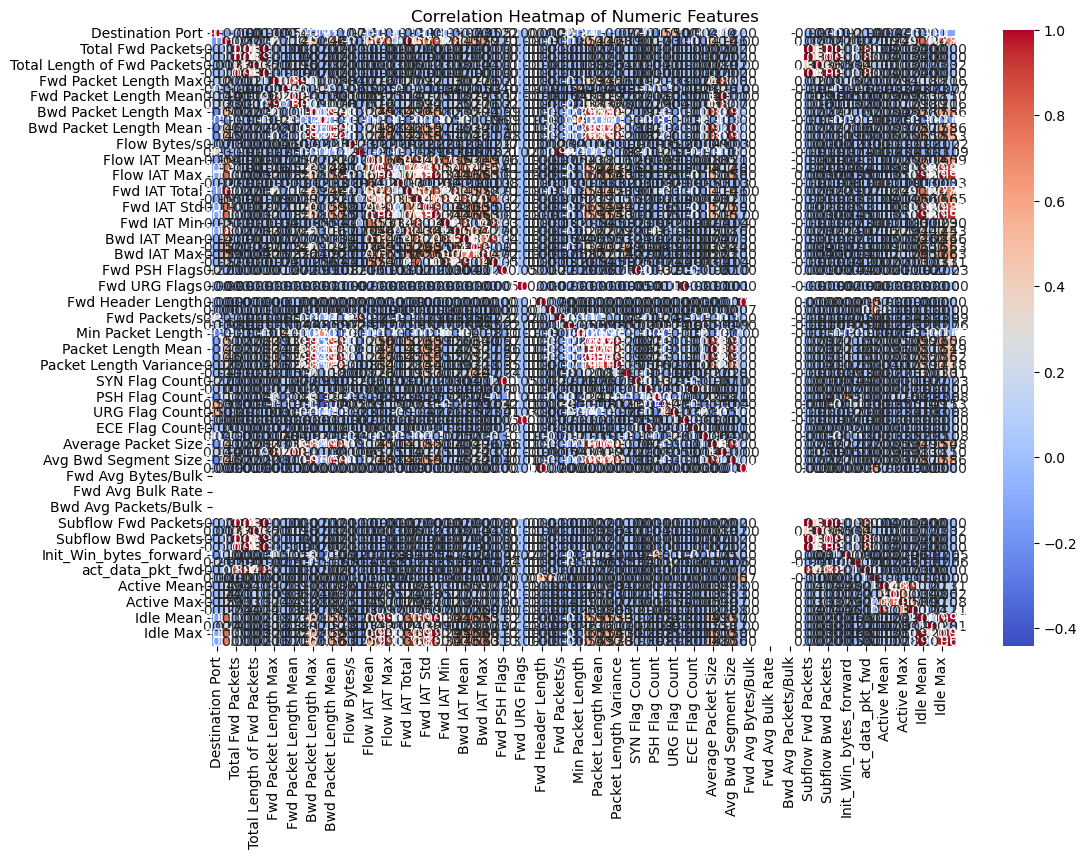

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

9. Do you recognize the columns that produce the black stripes? Answer where do you know them from and what they have in common. (1 Point)

These columns are constant features (always 0). We mentioned them in subtask 1.3 because they could throw off a classifier.

10. Besides the columns from subtask 9, you identified two other columns in subtask 3 that contain odd values. Research, why the dataset contains this kind of values. It is helpful to know, that the creators of the dataset used [CICFlowMeter](https://github.com/ahlashkari/CICFlowMeter/tree/master) for the measurements. You might also be interested in a paper related to this [topic](https://intrusion-detection.distrinet-research.be/WTMC2021/Resources/wtmc2021_Engelen_Troubleshooting.pdf). (2 Points)

- If the timestamps are in a wrong order (end date before begin date) the difference can be negative or lead to negative values in further calculations 
- Some implementations set -1 as placeholder
- for similar timestamps deviation errors can lead to an infinite value

### Task 2 – Cleaning the Dataset (7 Points)
This dataset has to be [cleaned](https://en.wikipedia.org/wiki/Data_cleansing), before we can use it.



1. Clean the white spaces from the column labels. (1 Point)

In [24]:
# clean white spaces from column names
df.columns = df.columns.str.strip()

2. Treat the columns with the "odd" values from task 1, subtask 3, each in its own sensible way. Thus, first answer for each of the three types of unusable values, how you want to treat them and why this is a prudent solution. (3 Points)

- Remove constant features (so they dont interfere with calculations)
- Replace negative values with None or Null (impossible values, remove so they dont interfere)
- Replace infiniite values with NaN, None or Null (better than undeterminable values)

3. Perform the cleanup you proposed in subtask 2 for all three columns. (3 Points)

In [25]:
# remove constant features
const_features = df.columns[df.nunique() == 1]
df = df.drop(columns=const_features)

# replace negative values with None
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].applymap(lambda x: np.nan if x < 0 else x) 

# replace infinite values with NaN
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

/tmp/ipykernel_139/2359296746.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[num_cols] = df[num_cols].applymap(lambda x: np.nan if x < 0 else x)


In [27]:
from sklearn.preprocessing import LabelEncoder
# print column statistics and data types
# Alle Spalten anzeigen
pd.set_option('display.max_columns', None)

# Optional: alle Zeilen anzeigen
pd.set_option('display.max_rows', None)

# Optional: max Spaltenbreite
pd.set_option('display.max_colwidth', None)

encoder = LabelEncoder()
df["Label_Num"] = encoder.fit_transform(df['Label'])

# Dann describe() ausgeben
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,NaN,NaN,NaN,8071.482501,18283.632173,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830628.0,NaN,NaN,NaN,14786264.627143,33654295.744642,0.0,155.0,31317.0,3206060.0,119999998.0
Total Fwd Packets,2830743.0,NaN,NaN,NaN,9.36116,749.672793,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,NaN,NaN,NaN,10.39377,997.388269,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,NaN,NaN,NaN,549.302415,9993.589229,0.0,12.0,62.0,187.0,12900000.0
Total Length of Bwd Packets,2830743.0,NaN,NaN,NaN,16162.642546,2263088.051709,0.0,0.0,123.0,482.0,655453030.0
Fwd Packet Length Max,2830743.0,NaN,NaN,NaN,207.599941,717.184842,0.0,6.0,37.0,81.0,24820.0
Fwd Packet Length Min,2830743.0,NaN,NaN,NaN,18.713656,60.339345,0.0,0.0,2.0,36.0,2325.0
Fwd Packet Length Mean,2830743.0,NaN,NaN,NaN,58.201939,186.091157,0.0,6.0,34.0,50.0,5940.857143
Fwd Packet Length Std,2830743.0,NaN,NaN,NaN,68.910134,281.187092,0.0,0.0,0.0,26.162951,7125.596846


### Task 3 – Preprocessing (10 Points)

Your goal in this task is to prepare the dataset to train a Deep Neural Network. Use the knowledge you gained in the exploration phase.

1. Reduce Memory usage by downcasting numeric values. Print the usage before and after the manipulation. (2 Points)

In [28]:
start_mem = df.memory_usage(deep=True).sum() / 1024**2

# Check memory usage before downcasting
before_mem = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage BEFORE downcasting: {before_mem:.2f} MB")

# Downcast numeric columns
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if df[col].dtype == 'int64':
        df[col] = pd.to_numeric(df[col], downcast='integer')
    elif df[col].dtype == 'float64':
        df[col] = pd.to_numeric(df[col], downcast='float')

# Check memory usage after downcasting
after_mem = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage AFTER downcasting: {after_mem:.2f} MB")
print(f"Memory reduced by: {before_mem - after_mem:.2f} MB")

Memory usage BEFORE downcasting: 1682.74 MB
Memory usage AFTER downcasting: 994.34 MB
Memory reduced by: 688.40 MB


2. Research the term "stratification" and explain in two sentences what could happen when not stratifying the training/validation/test splits of a dataset. (2 Points)

Distribution of class labels should be equal for test, validation and train splits. If not stratified the test set could omit columns that are important for classification (some feature represntations missing).

3. Split the the dataset for training, validation, and testing in the ratio (80/10/10) with a Random State of 0. Stratify the splits on the label. (2 Points)

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

# Assuming 'attack_column' is the label column
label_col = "Label_Num"

# First split: Train (80%) and Temp (20%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df[label_col],
    random_state=0
)

# Second split: Validation (10%) and Test (10%) from Temp
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,  # Half of 20% → 10%
    stratify=temp_df[label_col],
    random_state=0
)

# Print sizes
print(f"Training set size: {len(train_df)} rows")
print(f"Validation set size: {len(val_df)} rows")
print(f"Testing set size: {len(test_df)} rows")

Training set size: 2264594 rows
Validation set size: 283074 rows
Testing set size: 283075 rows


4. Shrink the largest class in the training set with [Random Under Sampling](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html). Enlarge all other classes with [Random Oversampling](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.RandomOverSampler.html). Use random state equals zero. In practice, you can use [Synthetic Minority Over-Sampling Technique](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTE.html) for better results with more computational power. (1 Point)

Before:  Counter({np.int8(0): 1818477, np.int8(4): 184858, np.int8(10): 127144, np.int8(2): 102421, np.int8(3): 8234, np.int8(7): 6350, np.int8(11): 4718, np.int8(6): 4637, np.int8(5): 4399, np.int8(1): 1573, np.int8(12): 1206, np.int8(14): 522, np.int8(9): 29, np.int8(13): 17, np.int8(8): 9})
After:  Counter({np.int8(4): 184858, np.int8(10): 127144, np.int8(2): 102421, np.int8(3): 8234, np.int8(7): 6350, np.int8(11): 4718, np.int8(6): 4637, np.int8(5): 4399, np.int8(1): 1573, np.int8(12): 1206, np.int8(14): 522, np.int8(9): 29, np.int8(13): 17, np.int8(0): 9, np.int8(8): 9})


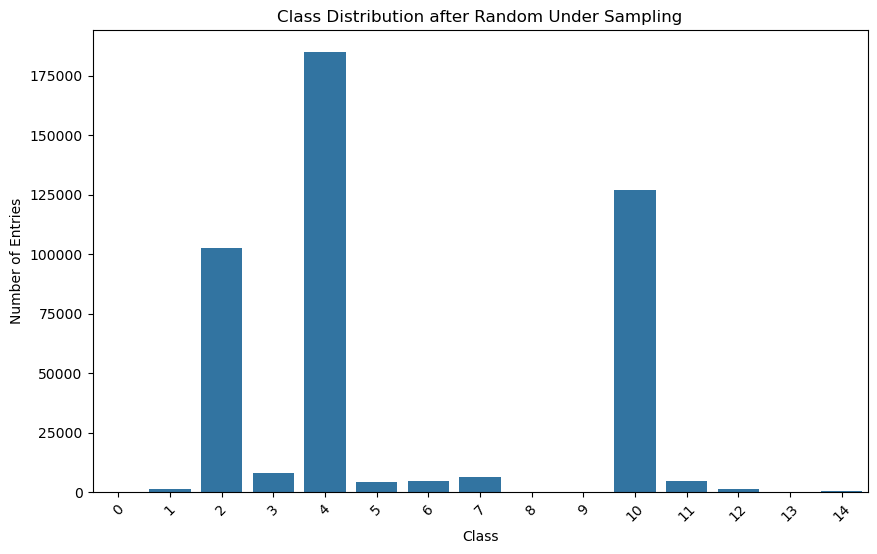

In [30]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Shrink largest class in training set with RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='majority', random_state=0)
X_train = train_df.drop(columns=[label_col, 'Label']).values
y_train = train_df[label_col].values
print('Before: ', Counter(y_train))
X_res, y_res = rus.fit_resample(X_train, y_train)
print('After: ', Counter(y_res))


# erstelle ein diagramm mit x achse der klassen und y achse der zugeordnete anzahl an einträgen
import matplotlib.pyplot as plt                 
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(x=y_res)
plt.title('Class Distribution after Random Under Sampling')
plt.xlabel('Class')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.show()
    

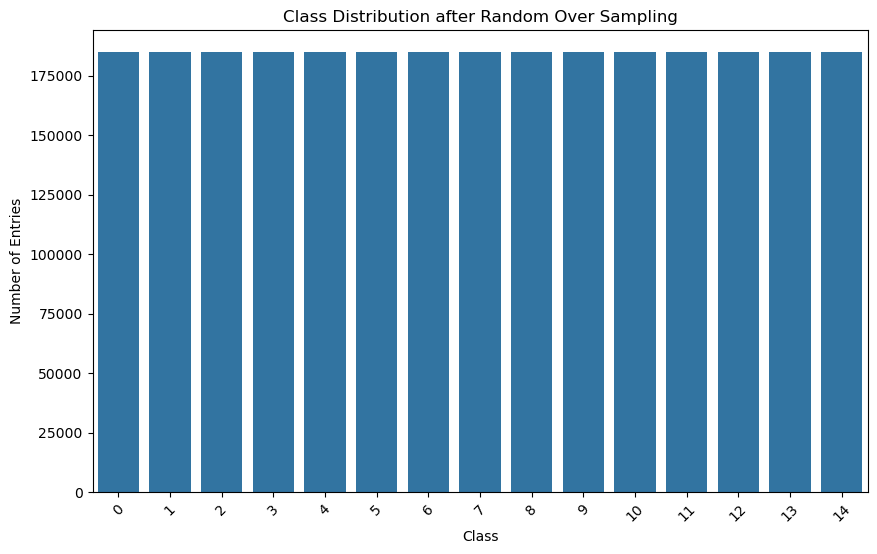

In [31]:
# upsample minority classes in training set with RandomOverSampler
ros = RandomOverSampler(sampling_strategy='not majority', random_state=0)
X_train_res, y_train_res = ros.fit_resample(X_res, y_res)           

# erstelle ein diagramm mit x achse der klassen und y achse der zugeordnete anzahl an einträgen
import matplotlib.pyplot as plt         
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(x=y_train_res)         
plt.title('Class Distribution after Random Over Sampling')
plt.xlabel('Class')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.show()  




In [32]:
# print count per class of resampled training set
import pandas as pd
from collections import Counter 
counter = Counter(y_train_res)
print("Class distribution after resampling:")
for cls, count in counter.items():
    print(f"Class '{cls}': {count} entries")    
    

Class distribution after resampling:
Class '0': 184858 entries
Class '1': 184858 entries
Class '2': 184858 entries
Class '3': 184858 entries
Class '4': 184858 entries
Class '5': 184858 entries
Class '6': 184858 entries
Class '7': 184858 entries
Class '8': 184858 entries
Class '9': 184858 entries
Class '10': 184858 entries
Class '11': 184858 entries
Class '12': 184858 entries
Class '13': 184858 entries
Class '14': 184858 entries


5. Instead of a normalization, which you did for the image classification task, here you should scale the dataset inputs for the Neural Network. (1 Point)

In [38]:
from sklearn.preprocessing import StandardScaler

#scale numeric features
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)



6. Convert the dataset splits (likely they are numpy values) into tensors. (1 Point)

In [104]:
import torch
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

y_train_res = y_train_res.reshape(-1, 1)

y_tensor = encoder.fit_transform(y_train_res)
y_test_tensor = encoder.fit_transform(test_df['Label_Num'].values.reshape(-1, 1))
y_val_tensor = encoder.fit_transform(val_df['Label_Num'].values.reshape(-1, 1))

X_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_tensor = torch.tensor(y_tensor, dtype=torch.float32)


X_test_tensor = torch.tensor(test_df.drop(columns=['Label', 'Label_Num']).values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_tensor, dtype=torch.float32)


X_val_tensor = torch.tensor(val_df.drop(columns=['Label', 'Label_Num']).values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_tensor, dtype=torch.float32)





7. Build a PyTorch dataset and dataloader. Shuffle the training dataset and use a 256 as batch size. (1 Point)

In [105]:
from torch.utils.data import TensorDataset, DataLoader

training_data_set = TensorDataset(X_tensor, y_tensor)
training_data_loader = DataLoader(training_data_set, batch_size=256, shuffle=True)


### Task 4 – Model Training and Validation (6 Points)

Train a Deep Neural Network to predict the attack classes.

In [106]:
import torch.nn as nn

class SmallIDSNet(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)

1. Briefly explain the architecture of the network above. (2 Points)

*your answer*

2. Create the model, the optimizer and the `BCEWithLogitsLoss` loss function. (1 Point)

In [107]:
import torch.optim as optim

LR          = 1e-5
EPOCHS      = 20
BATCH_SIZE  = 128

print(X_tensor.shape)

network = SmallIDSNet(70, 15)
optimizer = optim.NAdam(network.parameters(), lr=LR)

criterion = nn.BCEWithLogitsLoss()

torch.Size([2772870, 70])


In [108]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = X_tensor.to(device)
y_tensor = y_tensor.to(device)

network.to(device)


print(device)

cuda


3. Train the model and validate the results for every epoch. (2 Points)

In [ ]:
import numpy

for epoch in range(1, EPOCHS+1):

    losses, accuracies = [], []
    print(f"Epoch {epoch}", end='')
    for i, data in enumerate(training_data_loader, 0):
        inputs, labels = data
        print(inputs.shape)    
        print(labels.shape)   
        
        if torch.cuda.is_available():
            inputs = inputs.to('cuda')
            labels = labels.to('cuda')

            

        optimizer.zero_grad()

        print(type(inputs))
        
        outputs = network.forward(inputs)
        loss = criterion(outputs, labels)
        if i % 7 == 0:
            print()
        print("Batch: {:3}, Loss {:.4f}: ".format(i, loss), end=" ")

        loss.backward()
        optimizer.step()

        local_loss = loss.cpu()
        losses.append(loss.detach().numpy())
        avg_epoch_loss = numpy.asarray(losses).mean()
        avg_epoch_losses.append(avg_epoch_loss)
        print("\nEpoch {}, average loss: {:.04f}".format(epoch, avg_epoch_loss))
        
    print(f"Epoch {epoch:02d}")
    print(f"Train Loss: {avg_loss:.4f}")
    #print(f"Train Acc:{training_accuracy:.4f}")
    #print(f"Validation Acc: {val_accuracy:.4f}")
    print()

4. Save the trained model and the three splits of the dataset. (1 Point)